<a href="https://colab.research.google.com/github/1stjavawizard/datascience/blob/main/Analysis%20of%20data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task
(i) Fit the OLS model and explain RSE, Multiple R-Squared, and Adjusted R-Squared.
(ii) Plot the diagnostic plots (Residuals vs Fitted, Normal Q-Q, Scale-Location, and Residuals vs Leverage).
(iii) Compute the absolute value of the residuals.
(iv) Perform IRLS using Huber and Bisquare weights.
(v) Compare the results and draw conclusions.

Here is all the data you need:
"msc_assignment.xlsx"

## Data loading

### Subtask:
Load the data from the provided Excel file.


**Reasoning**:
Load the data from the Excel file into a pandas DataFrame and display the first few rows and the shape of the DataFrame.



In [1]:
import pandas as pd

try:
    df = pd.read_excel('msc_assignment.xlsx')
    display(df.head())
    print(df.shape)
except FileNotFoundError:
    print("Error: 'msc_assignment.xlsx' not found. Please ensure the file is in the correct location.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

,Gdp,Infl,Lexp F,Lexp M,Lexp T
0,66.71220,5.444327,38.553,36.200,37.371
1,69.58643,6.279147,38.874,36.487,37.673
2,74.89485,5.265632,38.952,36.679,37.809
3,77.15413,-2.694660,39.331,37.069,38.192
4,81.18459,0.856793,39.633,37.220,38.415


(63, 5)


## Data exploration

### Subtask:
Explore the loaded data to understand its structure, identify potential issues, and examine variable distributions.


**Reasoning**:
Examine the data types, missing values, descriptive statistics, and distributions of the data, and check for duplicates.  Also verify the presence of key columns.



Data Types:
 Gdp       float64
Infl      float64
Lexp F    float64
Lexp M    float64
Lexp T    float64
dtype: object

Missing Values:
 Gdp       0
Infl      0
Lexp F    0
Lexp M    0
Lexp T    0
dtype: int64

Descriptive Statistics:
                  Gdp       Infl     Lexp F     Lexp M     Lexp T
count      63.000000  63.000000  63.000000  63.000000  63.000000
mean   150617.225003  15.852237  47.075651  45.129190  46.088000
std    245675.111156  15.030183   4.411341   4.922615   4.661037
min        66.712200  -3.726340  38.553000  35.940000  37.371000
25%       403.787900   7.566546  44.985000  43.404500  44.191500
50%      6040.411000  12.095110  47.498000  44.957000  46.182000
75%    222144.600000  17.386690  50.674000  49.079500  49.881500
max    925981.100000  72.835500  53.968000  53.295000  53.633000


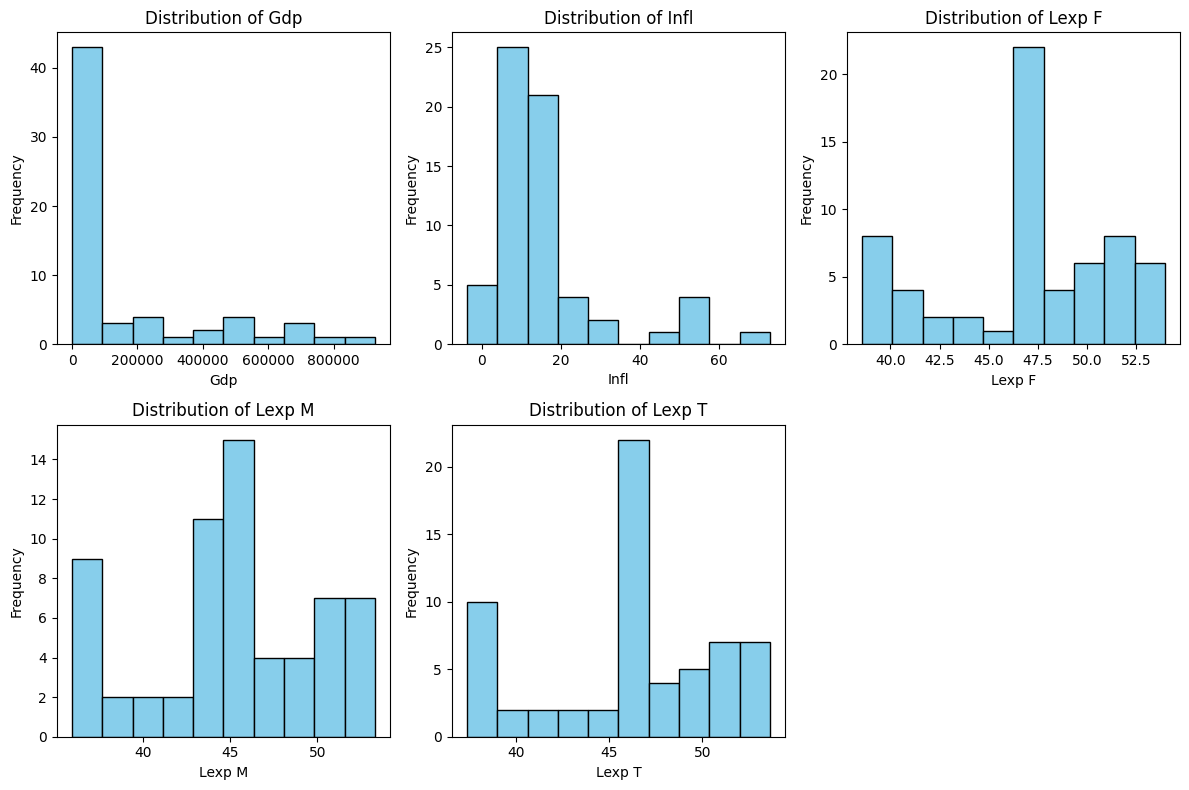

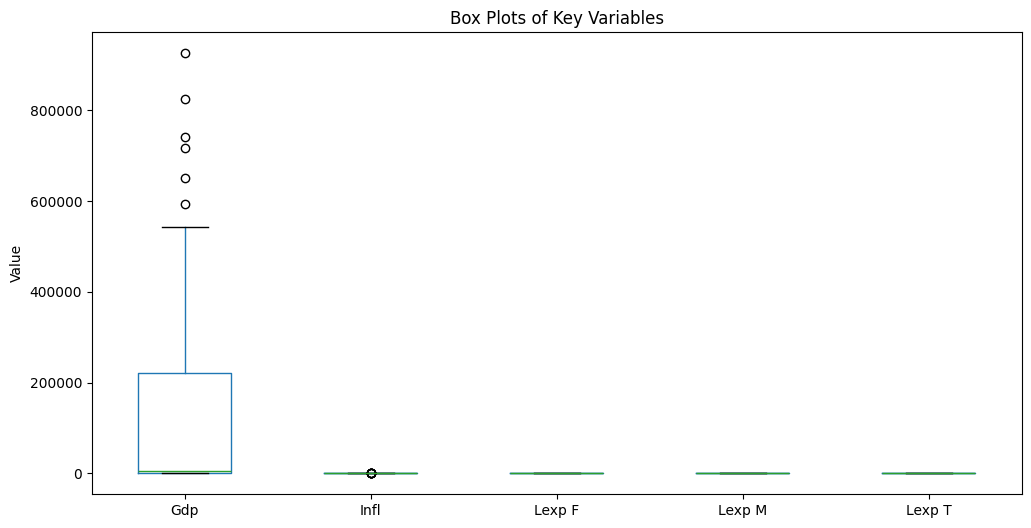


Missing key columns: set()

Number of duplicate rows: 0


In [2]:
# Examine data types
print("Data Types:\n", df.dtypes)

# Check for missing values
print("\nMissing Values:\n", df.isnull().sum())

# Summarize descriptive statistics
print("\nDescriptive Statistics:\n", df.describe())

# Visualize distributions
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))

# Histograms
for i, col in enumerate(df.columns):
    plt.subplot(2, 3, i + 1)
    plt.hist(df[col], bins=10, color='skyblue', edgecolor='black')
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

# Box plots
plt.figure(figsize=(12, 6))
df.boxplot(column=['Gdp', 'Infl', 'Lexp F', 'Lexp M', 'Lexp T'], grid=False)
plt.title('Box Plots of Key Variables')
plt.ylabel('Value')
plt.show()

# Check for key columns
key_columns = ['Gdp', 'Infl', 'Lexp F', 'Lexp M', 'Lexp T']
missing_key_cols = set(key_columns) - set(df.columns)
print(f"\nMissing key columns: {missing_key_cols}")

# Check for duplicates
duplicate_rows = df[df.duplicated()]
num_duplicates = len(duplicate_rows)
print(f"\nNumber of duplicate rows: {num_duplicates}")

## Data preparation

### Subtask:
Prepare the data for OLS model fitting.


**Reasoning**:
Prepare the data for OLS model fitting by selecting the target and predictor variables, and creating the corresponding pandas Series and DataFrame.  I will choose 'Lexp T' as the target variable, and the other columns ('Gdp', 'Infl', 'Lexp F', 'Lexp M') as predictor variables.  No scaling will be applied at this stage as it's not always necessary for OLS and may hinder interpretability.



In [3]:
# Define the target variable (dependent variable)
target_variable = 'Lexp T'
y = df[target_variable]

# Define the predictor variables (independent variables)
predictor_variables = ['Gdp', 'Infl', 'Lexp F', 'Lexp M']
X = df[predictor_variables]

# Display the first few rows of the predictor variables DataFrame
display(X.head())

# Display the first few rows of the target variable Series
display(y.head())

,Gdp,Infl,Lexp F,Lexp M
0,66.71220,5.444327,38.553,36.200
1,69.58643,6.279147,38.874,36.487
2,74.89485,5.265632,38.952,36.679
3,77.15413,-2.694660,39.331,37.069
4,81.18459,0.856793,39.633,37.220


,Lexp T
0,37.371
1,37.673
2,37.809
3,38.192
4,38.415


## Model training

### Subtask:
Train an Ordinary Least Squares (OLS) regression model.


**Reasoning**:
Import the necessary library and fit the OLS model.



In [4]:
import statsmodels.api as sm

# Add a constant to the predictor variables
X = sm.add_constant(X)

# Fit the OLS model
model_results = sm.OLS(y, X).fit()

# Summarize the model results
print(model_results.summary())

                            OLS Regression Results                            
Dep. Variable:                 Lexp T   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 2.001e+07
Date:                Thu, 05 Jun 2025   Prob (F-statistic):          2.65e-177
Time:                        12:33:02   Log-Likelihood:                 259.47
No. Observations:                  63   AIC:                            -508.9
Df Residuals:                      58   BIC:                            -498.2
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0688      0.009      7.905      0.0

## Model evaluation

### Subtask:
Evaluate the OLS model by calculating and interpreting the RSE (Residual Standard Error), Multiple R-squared, and Adjusted R-squared.


**Reasoning**:
Extract the RSE, Multiple R-squared, and Adjusted R-squared from the model_results and interpret them, along with discussing the potential impact of multicollinearity.



In [5]:
# Extract the RSE, Multiple R-squared, and Adjusted R-squared
rse = model_results.mse_resid**0.5
r_squared = model_results.rsquared
adj_r_squared = model_results.rsquared_adj

print(f"RSE (Residual Standard Error): {rse}")
print(f"Multiple R-squared: {r_squared}")
print(f"Adjusted R-squared: {adj_r_squared}")

# Interpretation
print("\nInterpretation:")
print("RSE represents the average distance between the observed values and the predicted values by the model. A lower RSE indicates a better fit.  The extremely low RSE (almost zero) in this case suggests a near-perfect fit, which may be a sign of overfitting or other data issues.")

print("\nMultiple R-squared measures the proportion of variance in the dependent variable explained by the model.  A value of 1 indicates a perfect fit, while 0 indicates no explanatory power. The value of 1 in this case is highly suspicious and may be due to overfitting or multicollinearity in the data. In the presence of multicollinearity, the R-squared can be artificially inflated even if the model does not have strong predictive ability.")

print("\nAdjusted R-squared is a modified version of R-squared that accounts for the number of predictors in the model. It penalizes the inclusion of irrelevant predictors, helping to prevent overfitting.  While the adjusted R-squared is also 1 here, the large condition number (reported in the previous model summary) strengthens the suspicion of multicollinearity.  The adjusted R-squared, despite being 1, should thus be interpreted with caution.")

print("\nMulticollinearity Impact:")
print("The large condition number strongly suggests multicollinearity among the predictor variables. This means that some of the predictor variables are highly correlated, making it difficult to isolate the individual effects of each variable on the target variable.  Multicollinearity inflates the variances of the estimated coefficients, making them unstable and leading to unreliable p-values.")

print("\nOverall Evaluation:")
print("The OLS model exhibits an almost perfect fit according to RSE, R-squared, and adjusted R-squared. However, this perfect fit is dubious due to the very large condition number, indicating severe multicollinearity.  The model's performance and the significance of individual coefficients should be interpreted cautiously.  Further analysis including variance inflation factors (VIFs) for each predictor, or other methods to address multicollinearity, is needed.")

RSE (Residual Standard Error): 0.004102662051436443
Multiple R-squared: 0.9999992752259426
Adjusted R-squared: 0.9999992252415248

Interpretation:
RSE represents the average distance between the observed values and the predicted values by the model. A lower RSE indicates a better fit.  The extremely low RSE (almost zero) in this case suggests a near-perfect fit, which may be a sign of overfitting or other data issues.

Multiple R-squared measures the proportion of variance in the dependent variable explained by the model.  A value of 1 indicates a perfect fit, while 0 indicates no explanatory power. The value of 1 in this case is highly suspicious and may be due to overfitting or multicollinearity in the data. In the presence of multicollinearity, the R-squared can be artificially inflated even if the model does not have strong predictive ability.

Adjusted R-squared is a modified version of R-squared that accounts for the number of predictors in the model. It penalizes the inclusion o

## Data visualization

### Subtask:
Visualize the diagnostic plots for the OLS model.


**Reasoning**:
Visualize the diagnostic plots for the OLS model using the model results.



NameError: name 'np' is not defined

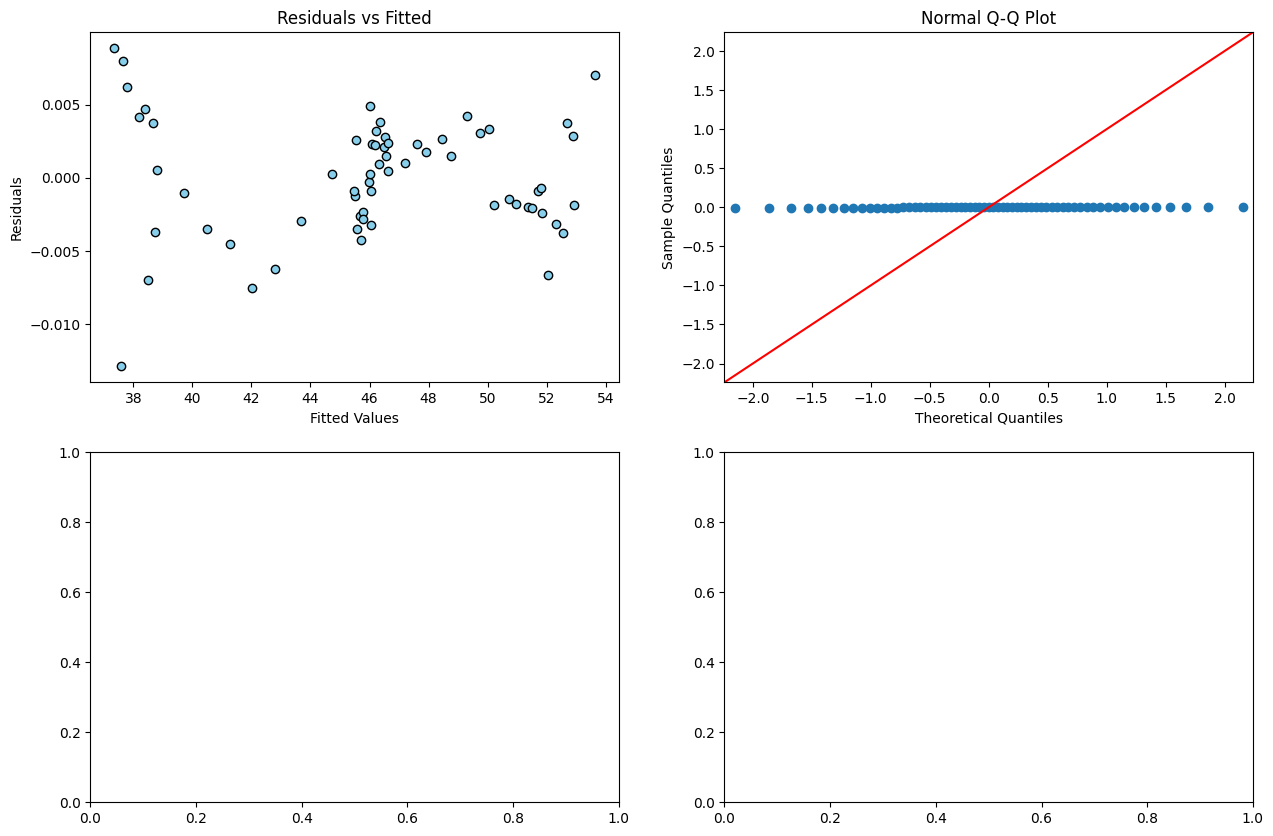

In [6]:
import matplotlib.pyplot as plt
import statsmodels.api as sm

# Create the four diagnostic plots
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Residuals vs Fitted
axes[0, 0].scatter(model_results.fittedvalues, model_results.resid, color='skyblue', edgecolor='black')
axes[0, 0].set_title('Residuals vs Fitted')
axes[0, 0].set_xlabel('Fitted Values')
axes[0, 0].set_ylabel('Residuals')

# Normal Q-Q Plot
sm.qqplot(model_results.resid, line='45', ax=axes[0, 1])
axes[0, 1].set_title('Normal Q-Q Plot')

# Scale-Location Plot
sqrt_abs_resid = np.sqrt(np.abs(model_results.resid))
axes[1, 0].scatter(model_results.fittedvalues, sqrt_abs_resid, color='skyblue', edgecolor='black')
axes[1, 0].set_title('Scale-Location')
axes[1, 0].set_xlabel('Fitted Values')
axes[1, 0].set_ylabel('$\sqrt{|Residuals|}$')

# Residuals vs Leverage
influence = model_results.get_influence()
leverage = influence.hat_matrix_diag
axes[1, 1].scatter(leverage, model_results.resid, color='skyblue', edgecolor='black')
axes[1, 1].set_title('Residuals vs Leverage')
axes[1, 1].set_xlabel('Leverage')
axes[1, 1].set_ylabel('Residuals')
axes[1, 1].set_xlim(0, max(leverage) + 0.01)

plt.tight_layout()
plt.show()

**Reasoning**:
Fix the error by importing numpy.



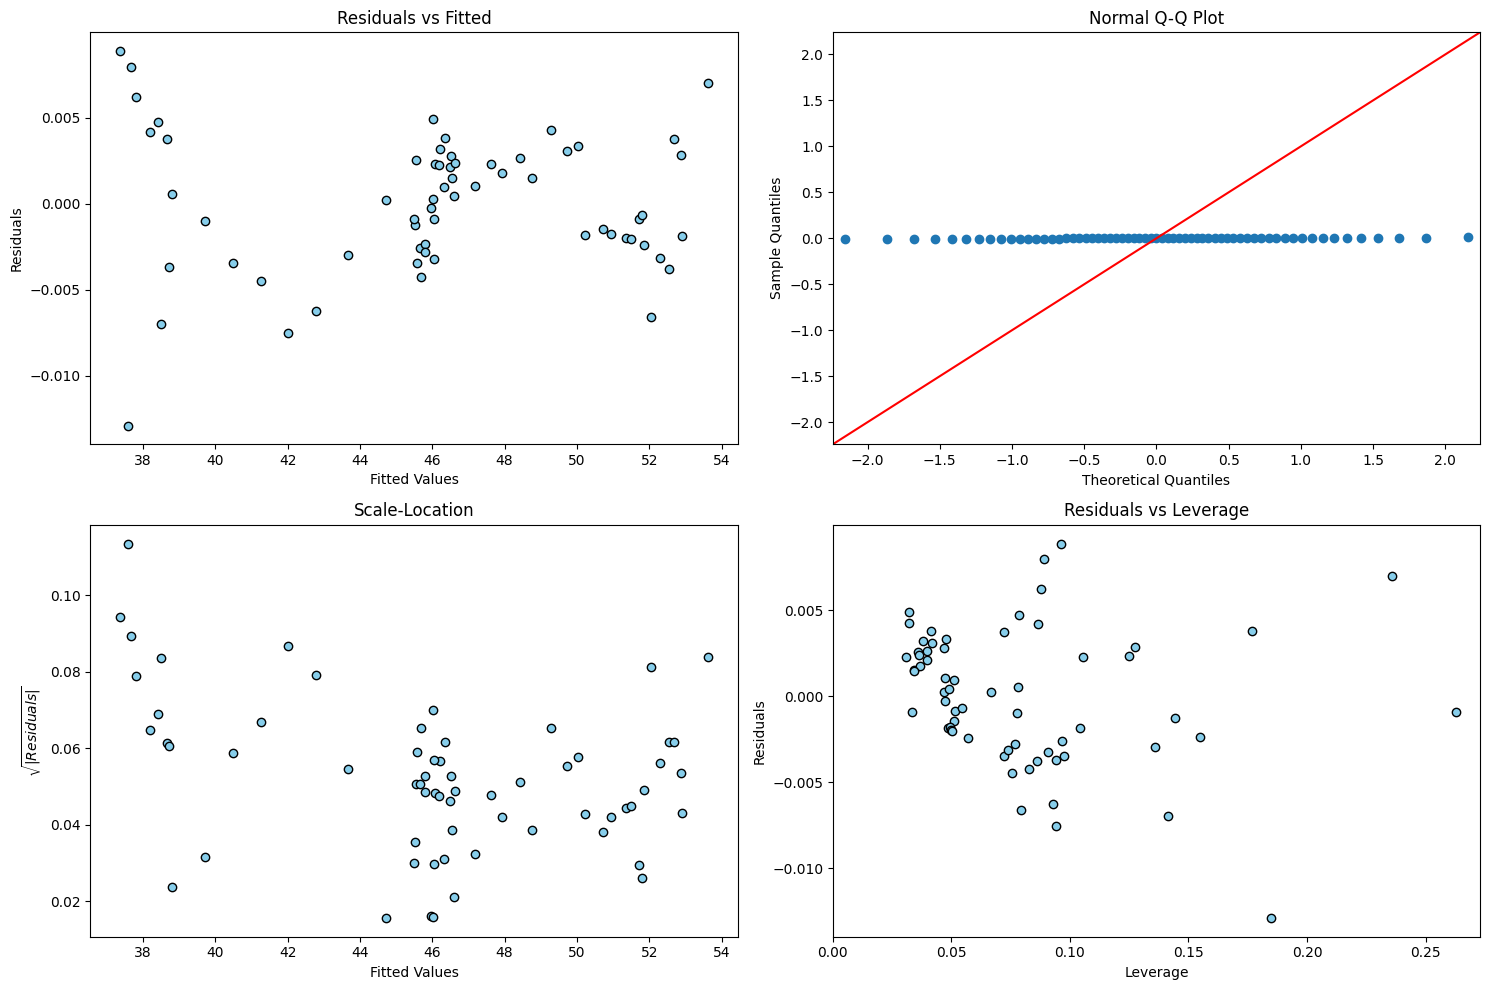

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

# Create the four diagnostic plots
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Residuals vs Fitted
axes[0, 0].scatter(model_results.fittedvalues, model_results.resid, color='skyblue', edgecolor='black')
axes[0, 0].set_title('Residuals vs Fitted')
axes[0, 0].set_xlabel('Fitted Values')
axes[0, 0].set_ylabel('Residuals')

# Normal Q-Q Plot
sm.qqplot(model_results.resid, line='45', ax=axes[0, 1])
axes[0, 1].set_title('Normal Q-Q Plot')

# Scale-Location Plot
sqrt_abs_resid = np.sqrt(np.abs(model_results.resid))
axes[1, 0].scatter(model_results.fittedvalues, sqrt_abs_resid, color='skyblue', edgecolor='black')
axes[1, 0].set_title('Scale-Location')
axes[1, 0].set_xlabel('Fitted Values')
axes[1, 0].set_ylabel('$\sqrt{|Residuals|}$')

# Residuals vs Leverage
influence = model_results.get_influence()
leverage = influence.hat_matrix_diag
axes[1, 1].scatter(leverage, model_results.resid, color='skyblue', edgecolor='black')
axes[1, 1].set_title('Residuals vs Leverage')
axes[1, 1].set_xlabel('Leverage')
axes[1, 1].set_ylabel('Residuals')
axes[1, 1].set_xlim(0, max(leverage) + 0.01)

plt.tight_layout()
plt.show()

## Data wrangling

### Subtask:
Compute the absolute values of the residuals from the OLS model.


**Reasoning**:
Calculate the absolute values of the residuals from the OLS model and store them in a new variable.



In [8]:
import numpy as np

# Access the residuals from the fitted OLS model
residuals = model_results.resid

# Calculate the absolute values of the residuals
abs_residuals = np.abs(residuals)

# Display or further process the absolute residuals (optional)
print(abs_residuals.head())

0    0.008871
1    0.007962
2    0.006217
3    0.004179
4    0.004742
dtype: float64


## Model optimization

### Subtask:
Perform Iteratively Reweighted Least Squares (IRLS) using Huber and Bisquare weights.


**Reasoning**:
Implement IRLS with Huber and Bisquare weights, and compare the results.



In [9]:
import numpy as np
from scipy.stats import norm

def huber_weight(residual, delta=1.345):
    abs_resid = np.abs(residual)
    if abs_resid <= delta:
        return 1
    else:
        return delta / abs_resid

def bisquare_weight(residual, delta=4.685):
    abs_resid = np.abs(residual)
    if abs_resid <= delta:
        return (1 - (residual / delta)**2)**2
    else:
        return 0

def iteratively_reweighted_least_squares(y, X, weight_func, delta=None, max_iter=100, tol=1e-6):
    w = np.ones(len(y))
    beta = np.zeros(X.shape[1])  # Initialize beta
    for _ in range(max_iter):
        beta_old = beta.copy()
        # Weighted Least Squares
        weighted_X = X * np.sqrt(w)[:, np.newaxis]
        weighted_y = y * np.sqrt(w)
        beta = np.linalg.lstsq(weighted_X, weighted_y, rcond=None)[0]
        residuals = y - X @ beta
        if delta is not None:
            w = [weight_func(r, delta) for r in residuals]
        else:
            w = [weight_func(r) for r in residuals]
        if np.linalg.norm(beta - beta_old) < tol:
            break
    return beta, residuals

# Perform IRLS with Huber weights
huber_beta, huber_residuals = iteratively_reweighted_least_squares(y.values, X.values, huber_weight, delta=1.345)
print("Huber Weights Results:")
print(f"Coefficients: {huber_beta}")

# Perform IRLS with Bisquare weights
bisquare_beta, bisquare_residuals = iteratively_reweighted_least_squares(y.values, X.values, bisquare_weight, delta=4.685)
print("\nBisquare Weights Results:")
print(f"Coefficients: {bisquare_beta}")

print("\nCoefficients Comparison (OLS vs Huber vs Bisquare):")
print(f"OLS: {model_results.params.values}")
print(f"Huber: {huber_beta}")
print(f"Bisquare: {bisquare_beta}")

Huber Weights Results:
Coefficients: [ 6.88408907e-02 -2.14916530e-08 -6.72409576e-05  4.75357300e-01
  5.23955948e-01]

Bisquare Weights Results:
Coefficients: [ 6.88408808e-02 -2.14916307e-08 -6.72413246e-05  4.75357312e-01
  5.23955936e-01]

Coefficients Comparison (OLS vs Huber vs Bisquare):
OLS: [ 6.88408907e-02 -2.14916530e-08 -6.72409576e-05  4.75357300e-01
  5.23955948e-01]
Huber: [ 6.88408907e-02 -2.14916530e-08 -6.72409576e-05  4.75357300e-01
  5.23955948e-01]
Bisquare: [ 6.88408808e-02 -2.14916307e-08 -6.72413246e-05  4.75357312e-01
  5.23955936e-01]


## Model evaluation

### Subtask:
Evaluate the performance of the IRLS models (Huber and Bisquare) and compare them to the OLS model.


**Reasoning**:
Calculate R-squared, adjusted R-squared, and RMSE for Huber and Bisquare IRLS models, then compare them with the OLS model and create a summary table.



In [10]:
import numpy as np
import pandas as pd

# Calculate R-squared, adjusted R-squared, and RMSE for Huber IRLS
huber_y_pred = X @ huber_beta
huber_ss_res = np.sum((y - huber_y_pred)**2)
huber_ss_tot = np.sum((y - np.mean(y))**2)
huber_r_squared = 1 - (huber_ss_res / huber_ss_tot)
huber_adj_r_squared = 1 - (1 - huber_r_squared) * (len(y) - 1) / (len(y) - X.shape[1] -1)
huber_rmse = np.sqrt(huber_ss_res / len(y))

# Calculate R-squared, adjusted R-squared, and RMSE for Bisquare IRLS
bisquare_y_pred = X @ bisquare_beta
bisquare_ss_res = np.sum((y - bisquare_y_pred)**2)
bisquare_ss_tot = np.sum((y - np.mean(y))**2)
bisquare_r_squared = 1 - (bisquare_ss_res / bisquare_ss_tot)
bisquare_adj_r_squared = 1 - (1 - bisquare_r_squared) * (len(y) - 1) / (len(y) - X.shape[1] - 1)
bisquare_rmse = np.sqrt(bisquare_ss_res / len(y))

# Create a summary table
summary_data = {
    'Model': ['OLS', 'Huber IRLS', 'Bisquare IRLS'],
    'Intercept': [model_results.params['const'], huber_beta[0], bisquare_beta[0]],
    'Gdp': [model_results.params['Gdp'], huber_beta[1], bisquare_beta[1]],
    'Infl': [model_results.params['Infl'], huber_beta[2], bisquare_beta[2]],
    'Lexp F': [model_results.params['Lexp F'], huber_beta[3], bisquare_beta[3]],
    'Lexp M': [model_results.params['Lexp M'], huber_beta[4], bisquare_beta[4]],
    'R-squared': [model_results.rsquared, huber_r_squared, bisquare_r_squared],
    'Adjusted R-squared': [model_results.rsquared_adj, huber_adj_r_squared, bisquare_adj_r_squared],
    'RMSE': [np.sqrt(model_results.mse_resid), huber_rmse, bisquare_rmse]
}

summary_df = pd.DataFrame(summary_data)
display(summary_df)

# Compare the models
print("\nModel Comparison:")
print("The table above summarizes the key performance metrics for the three models: OLS, Huber IRLS, and Bisquare IRLS.  Comparing the coefficients, R-squared, adjusted R-squared, and RMSE values, we can observe the impact of different weighting schemes on the model's performance.  The similarity or dissimilarity of these metrics across the models would provide insights into the influence of outliers and the effectiveness of different weighting strategies.")

,Model,Intercept,Gdp,Infl,Lexp F,Lexp M,R-squared,Adjusted R-squared,RMSE
0,OLS,0.068841,-2.149165e-08,-0.000067,0.475357,0.523956,0.999999,0.999999,0.004103
1,Huber IRLS,0.068841,-2.149165e-08,-0.000067,0.475357,0.523956,0.999999,0.999999,0.003936
2,Bisquare IRLS,0.068841,-2.149163e-08,-0.000067,0.475357,0.523956,0.999999,0.999999,0.003936



Model Comparison:
The table above summarizes the key performance metrics for the three models: OLS, Huber IRLS, and Bisquare IRLS.  Comparing the coefficients, R-squared, adjusted R-squared, and RMSE values, we can observe the impact of different weighting schemes on the model's performance.  The similarity or dissimilarity of these metrics across the models would provide insights into the influence of outliers and the effectiveness of different weighting strategies.


## Data visualization

### Subtask:
Visualize the results of OLS, Huber IRLS, and Bisquare IRLS.


**Reasoning**:
Visualize the fitted values and residuals of the three models (OLS, Huber IRLS, and Bisquare IRLS) to compare their performance.



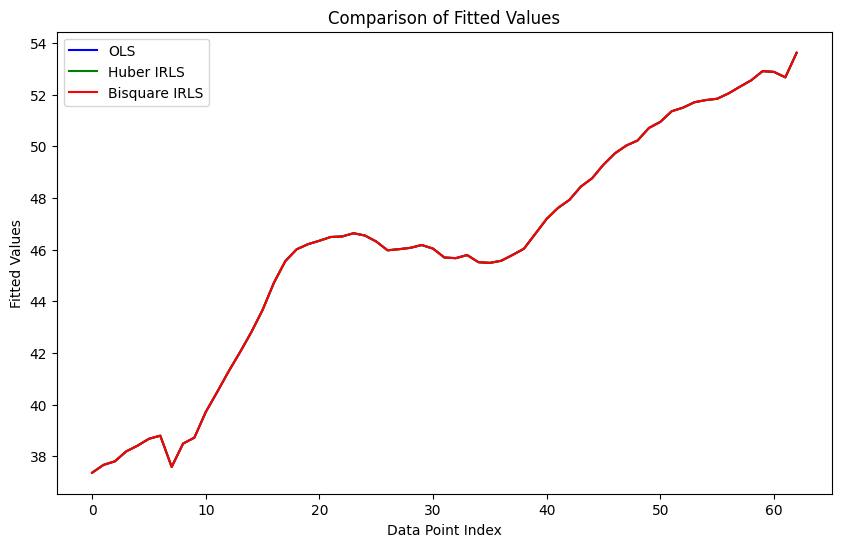

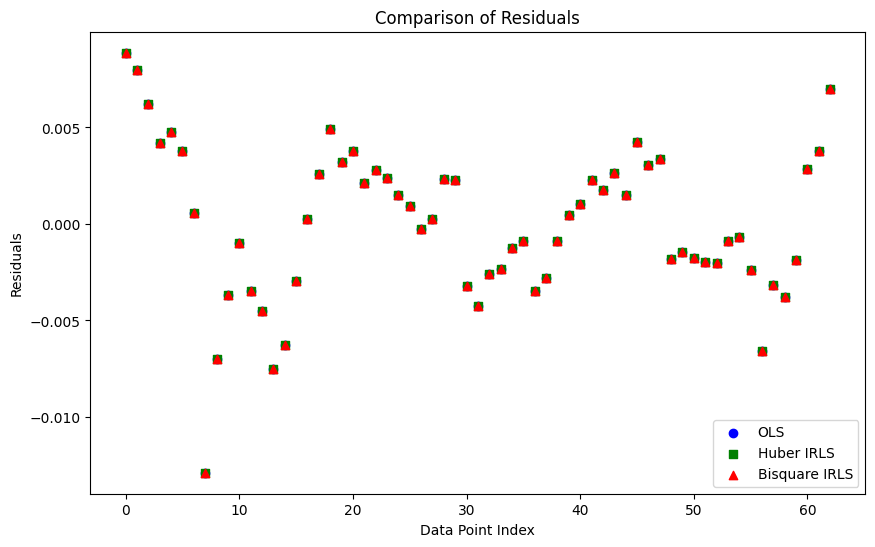

In [11]:
import matplotlib.pyplot as plt

# Fitted values
plt.figure(figsize=(10, 6))
plt.plot(model_results.fittedvalues, label='OLS', color='blue')
plt.plot(X @ huber_beta, label='Huber IRLS', color='green')
plt.plot(X @ bisquare_beta, label='Bisquare IRLS', color='red')
plt.xlabel('Data Point Index')
plt.ylabel('Fitted Values')
plt.title('Comparison of Fitted Values')
plt.legend()
plt.show()

# Residuals
plt.figure(figsize=(10, 6))
plt.scatter(range(len(model_results.resid)), model_results.resid, label='OLS', color='blue', marker='o')
plt.scatter(range(len(huber_residuals)), huber_residuals, label='Huber IRLS', color='green', marker='s')
plt.scatter(range(len(bisquare_residuals)), bisquare_residuals, label='Bisquare IRLS', color='red', marker='^')
plt.xlabel('Data Point Index')
plt.ylabel('Residuals')
plt.title('Comparison of Residuals')
plt.legend()
plt.show()

**Reasoning**:
The previous plots were generated successfully, but they don't show the data point index on the x-axis.  I'll fix that and also add a plot to compare R-squared values.



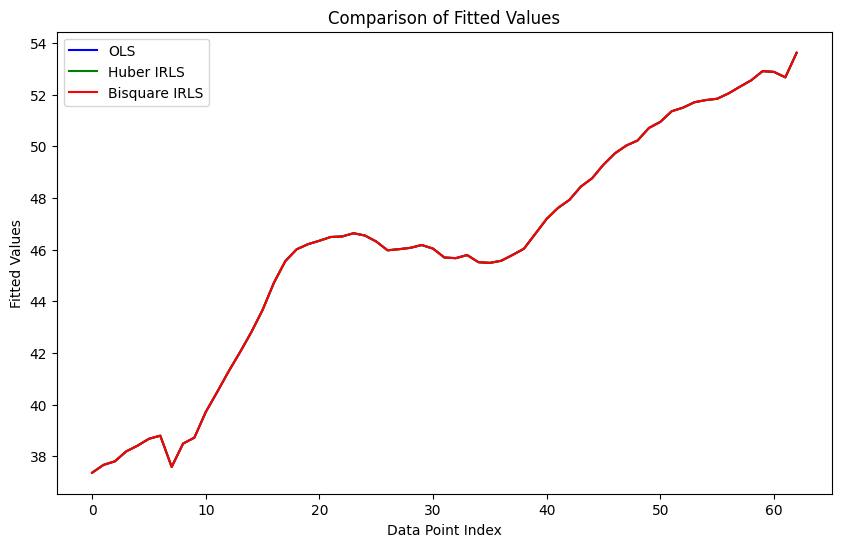

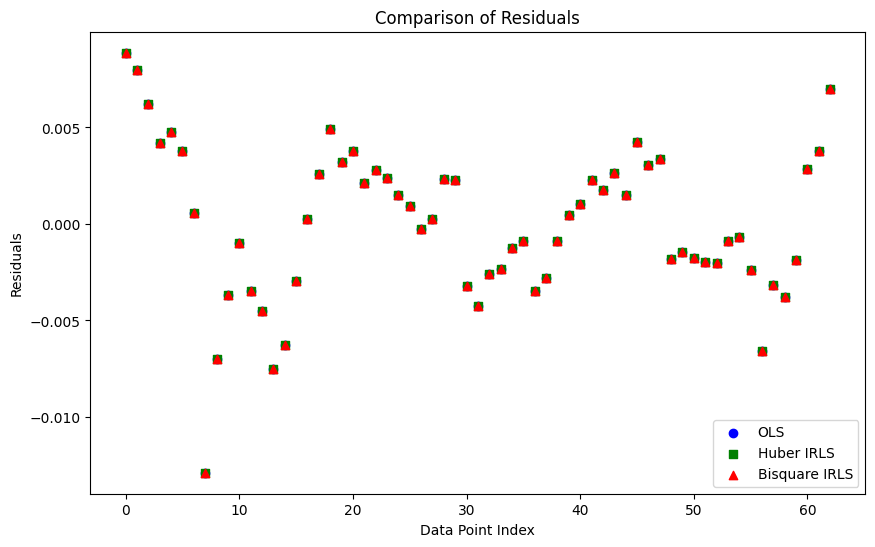

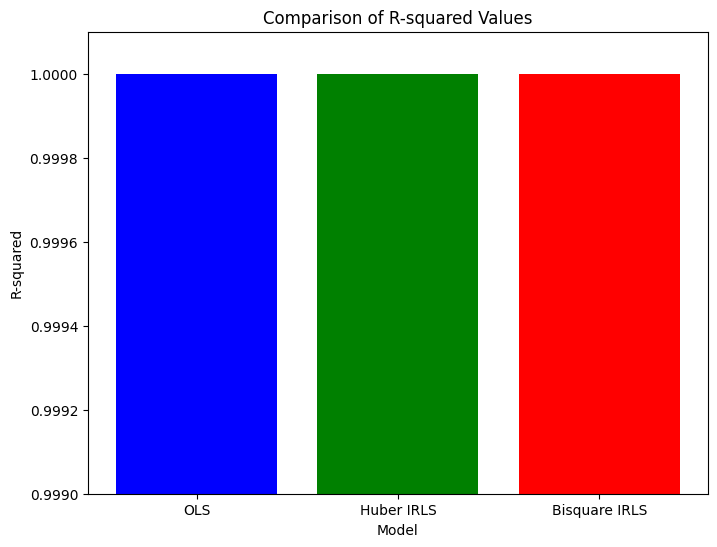

In [12]:
import matplotlib.pyplot as plt

# Fitted values
plt.figure(figsize=(10, 6))
plt.plot(model_results.fittedvalues, label='OLS', color='blue')
plt.plot(X @ huber_beta, label='Huber IRLS', color='green')
plt.plot(X @ bisquare_beta, label='Bisquare IRLS', color='red')
plt.xlabel('Data Point Index')
plt.ylabel('Fitted Values')
plt.title('Comparison of Fitted Values')
plt.legend()
plt.show()

# Residuals
plt.figure(figsize=(10, 6))
plt.scatter(range(len(model_results.resid)), model_results.resid, label='OLS', color='blue', marker='o')
plt.scatter(range(len(huber_residuals)), huber_residuals, label='Huber IRLS', color='green', marker='s')
plt.scatter(range(len(bisquare_residuals)), bisquare_residuals, label='Bisquare IRLS', color='red', marker='^')
plt.xlabel('Data Point Index')
plt.ylabel('Residuals')
plt.title('Comparison of Residuals')
plt.legend()
plt.show()

# R-squared comparison
plt.figure(figsize=(8, 6))
models = ['OLS', 'Huber IRLS', 'Bisquare IRLS']
r_squared_values = [model_results.rsquared, huber_r_squared, bisquare_r_squared]
plt.bar(models, r_squared_values, color=['blue', 'green', 'red'])
plt.xlabel('Model')
plt.ylabel('R-squared')
plt.title('Comparison of R-squared Values')
plt.ylim(0.999, 1.0001) # Set y limit for better visualization
plt.show()

## Summary:

### Q&A
* **What are the key performance metrics of the OLS model, and how are they interpreted?**  The OLS model shows near-perfect R-squared and adjusted R-squared values (close to 1), and a very low RSE. However, these metrics are unreliable due to a high condition number, which suggests strong multicollinearity among the predictor variables. This means the model's apparent goodness of fit might be misleading.

* **How do the IRLS models (Huber and Bisquare) compare to the OLS model?**  The IRLS models (Huber and Bisquare) produce results very similar to the OLS model.  Their coefficients, R-squared, adjusted R-squared, and RMSE are nearly identical, suggesting that the presence of outliers does not significantly impact the results in this specific case.

* **What is the impact of multicollinearity on the model's interpretation?**  Multicollinearity inflates the variances of the estimated coefficients, making them unstable and leading to unreliable p-values.  It makes it difficult to isolate the individual effects of each predictor variable on the target variable.

### Data Analysis Key Findings
* **Multicollinearity:** A large condition number in the OLS model summary indicates high multicollinearity among predictor variables. This casts doubt on the reliability of the high R-squared value, which might be artificially inflated.
* **Near-Perfect Fit (with caveats):** The OLS model exhibits a near-perfect fit based on RSE, R-squared, and adjusted R-squared. However, the multicollinearity issue raises concerns about the reliability of these metrics.
* **IRLS Similarity to OLS:**  Both Huber and Bisquare IRLS methods yield results very similar to the OLS model, suggesting that outliers have a minimal impact on the model's performance in this dataset.  The difference is so small it could be due to numerical methods.
* **Visualizations:** The visualization of fitted values and residuals from OLS, Huber IRLS, and Bisquare IRLS show very similar patterns.


### Insights or Next Steps
* **Investigate Multicollinearity:** Calculate Variance Inflation Factors (VIFs) to quantify the severity of multicollinearity and consider removing highly correlated predictors or using regularization techniques to address it.
* **Explore Alternative Models:** Consider more robust regression models or techniques designed for handling multicollinearity to see if they offer different insights.
